# A. Importation of libraries and Configs

In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
import os

# Change the current working directory
os.chdir(r".")

# Verify the change
print("New Current Directory:", os.getcwd())

New Current Directory: .


# B. Loading of datasets

## 1. Revenues

In [ ]:
df_revenues = pd.read_excel(args.dataset_dir)

In [ ]:
df_revenues

## 2. Enrollees

In [ ]:
df_enrollees = pd.read_excel(args.enrollees_dir)

In [ ]:
df_enrollees

## 3. Credit Sales

In [ ]:
df_credit_sales

# C. Testing saved models

In [1]:
import os
import re
import json
import pickle
import sqlite3

import pandas as pd


# ══════════════════════════════════════════════════════════════════════════════
#  DESERIALIZATION HELPERS  (load-side only)
# ══════════════════════════════════════════════════════════════════════════════

def _try_json_loads(value):
    """Attempt to deserialize a JSON string; return the original value on failure."""
    if not isinstance(value, str):
        return value
    try:
        return json.loads(value)
    except (json.JSONDecodeError, ValueError):
        return value


def _load_sqlite(run_folder_path: str):
    """
    Load results, class_mappings, survival_results, and metadata from
    results.db inside *run_folder_path*.

    Columns that contain JSON-serialized dicts or lists are automatically
    deserialized back to native Python objects.

    Returns
    -------
    pd.DataFrame, dict, dict, dict
    """
    db_path = os.path.join(run_folder_path, "results.db")
    con = sqlite3.connect(db_path)
    try:
        model_results_df = pd.read_sql("SELECT * FROM results", con)

        for col in model_results_df.columns:
            if model_results_df[col].dtype == object:
                model_results_df[col] = model_results_df[col].apply(_try_json_loads)

        row = con.execute("SELECT data FROM class_mappings WHERE id=1").fetchone()
        class_mappings = json.loads(row[0]) if row else {}

        # survival_results table may not exist in older databases
        try:
            row = con.execute("SELECT data FROM survival_results WHERE id=1").fetchone()
            survival_results = json.loads(row[0]) if row else {}
        except sqlite3.OperationalError:
            survival_results = {}

        row = con.execute("SELECT data FROM metadata WHERE id=1").fetchone()
        metadata = json.loads(row[0]) if row else {}

    finally:
        con.close()

    return model_results_df, class_mappings, survival_results, metadata


# ══════════════════════════════════════════════════════════════════════════════
#  PUBLIC LOAD FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def load_training_results(run_folder_path: str):
    """
    Load training results, class mappings, survival results, and metadata
    from a run folder.  Automatically detects the storage format (pickle,
    Excel, or SQLite) from the metadata recorded at save time.

    Parameters
    ----------
    run_folder_path : str
        Path to the run folder created by save_training_results.

    Returns
    -------
    pd.DataFrame, dict, dict, dict
        Results DataFrame, class mappings, survival results, metadata.
    """
    db_path = os.path.join(run_folder_path, "results.db")
    if os.path.exists(db_path) and not os.path.exists(
        os.path.join(run_folder_path, "metadata.json")
    ):
        return _load_sqlite(run_folder_path)

    with open(os.path.join(run_folder_path, "metadata.json"), "r") as f:
        metadata = json.load(f)

    fmt = metadata.get("results_format", "pickle")

    if fmt == "sqlite":
        return _load_sqlite(run_folder_path)
    elif fmt == "excel":
        model_results_df = pd.read_excel(os.path.join(run_folder_path, "results.xlsx"))
    else:
        with open(os.path.join(run_folder_path, "results.pkl"), "rb") as f:
            model_results_df = pickle.load(f)

    with open(os.path.join(run_folder_path, "class_mappings.json"), "r") as f:
        class_mappings = json.load(f)

    survival_results_path = os.path.join(run_folder_path, "survival_results.json")
    if os.path.exists(survival_results_path):
        with open(survival_results_path, "r") as f:
            survival_results = json.load(f)
    else:
        survival_results = {}

    return model_results_df, class_mappings, survival_results, metadata


# ══════════════════════════════════════════════════════════════════════════════
#  SESSION STORE
# ══════════════════════════════════════════════════════════════════════════════

_DATE_RE = re.compile(r"^\d{4}_\d{2}_\d{2}_\d{2}$")   # YYYY_MM_DD_##


class SessionStore:
    """
    Navigates and loads training sessions saved under a results root folder.

    Each session is a dated sub-folder whose name matches ``YYYY_MM_DD_##``
    (e.g. ``2025_03_05_02``).  Sessions are always ordered newest-first, so
    index ``0`` is the most recent run.

    Parameters
    ----------
    results_root : str
        Path to the directory that contains dated session folders.

    Examples
    --------
    >>> store = SessionStore("Results/")
    >>> store.list()
    ['2025_03_05_02', '2025_03_05_01', '2025_03_04_01']
    >>> store.load()                   # latest
    >>> store.load(1)                  # second-most-recent by index
    >>> store.load("2025_03_04_01")    # by exact folder name
    >>> store.path()                   # just the db path, no loading
    >>> store.path(2)
    """

    def __init__(self, results_root: str) -> None:
        self.results_root = results_root

    # ── Discovery ─────────────────────────────────────────────────────────────

    def list(self) -> list[str]:
        """
        Return all dated session folder names, newest first.

        Returns an empty list when no sessions exist yet rather than raising.
        """
        try:
            return sorted(
                [d for d in os.listdir(self.results_root) if _DATE_RE.match(d)],
                reverse=True,
            )
        except FileNotFoundError:
            return []

    # ── Internal resolver ─────────────────────────────────────────────────────

    def _resolve(self, session: "str | int | None") -> str:
        """
        Resolve a session reference to an absolute run-folder path.

        Parameters
        ----------
        session : str, int, or None
            - ``None`` → most-recent session (index 0).
            - ``int``  → zero-based index into :meth:`list` (0 = newest).
            - ``str``  → exact folder name (e.g. ``"2025_03_05_01"``).

        Raises
        ------
        FileNotFoundError
            If no sessions exist, or the named session is not found.
        IndexError
            If an integer index is out of range.
        """
        dirs = self.list()
        if not dirs:
            raise FileNotFoundError(
                f"No dated session folders found under {self.results_root!r}"
            )

        if session is None or isinstance(session, int):
            idx = 0 if session is None else session
            if idx < 0 or idx >= len(dirs):
                raise IndexError(
                    f"Session index {idx} is out of range — "
                    f"only {len(dirs)} session(s) available."
                )
            folder = dirs[idx]
        else:
            if session not in dirs:
                raise FileNotFoundError(
                    f"Session {session!r} not found under {self.results_root!r}"
                )
            folder = session

        return os.path.join(self.results_root, folder)

    # ── Path access ───────────────────────────────────────────────────────────

    def path(self, session: "str | int | None" = None) -> str:
        """
        Return the path to ``results.db`` for the given session without
        loading its contents.

        Parameters
        ----------
        session : str, int, or None
            See :meth:`_resolve` for accepted values.  Defaults to the
            most-recent session.

        Returns
        -------
        str
            Absolute path to ``results.db``.
        """
        run_folder = self._resolve(session)
        db_path    = os.path.join(run_folder, "results.db")
        if not os.path.exists(db_path):
            raise FileNotFoundError(f"results.db not found in {run_folder!r}")
        return db_path

    # ── Loading ───────────────────────────────────────────────────────────────

    def load(self, session: "str | int | None" = None) -> dict:
        """
        Load a training session and return its contents as a plain dict.

        Parameters
        ----------
        session : str, int, or None
            - ``None`` → most-recent session (default).
            - ``int``  → zero-based index (0 = newest).
            - ``str``  → exact folder name.

        Returns
        -------
        dict with keys:
            model_results_df   – pd.DataFrame of experiment results
            class_mappings     – dict of original label → encoded int
            survival_results   – dict with best_c_index,
                                 best_surv_parameters, best_time_points
            metadata           – dict of run metadata
        """
        run_folder          = self._resolve(session)
        df, cls, surv, meta = load_training_results(run_folder)

        return {
            "model_results_df": df,
            "class_mappings":   cls,
            "survival_results": surv,
            "metadata":         meta,
        }

In [32]:
#from src.modules.machine_learning.utils.io.load_results_from_folder import SessionStore

results_root = r".\Results - Backup"
session = SessionStore(results_root)

In [33]:
results = session.load('2026_03_08_02')

In [34]:
results.keys()

dict_keys(['model_results_df', 'class_mappings', 'survival_results', 'metadata'])

In [35]:
drop_columns = ['baseline_confusion_matrix',
           'enhanced_confusion_matrix',
           'baseline_roc_curve',
           'baseline_pr_curve',
           'enhanced_roc_curve',
           'enhanced_pr_curve']


results_df = results['model_results_df'].drop(columns=drop_columns)

In [36]:
results_df.columns

Index(['model', 'parameters', 'balance_strategy', 'baseline_accuracy',
       'baseline_precision_macro', 'baseline_recall_macro',
       'baseline_f1_macro', 'baseline_roc_auc_macro',
       'baseline_feature_method', 'baseline_feature_parameters',
       'baseline_feature_selected', 'baseline_feature_weights',
       'enhanced_accuracy', 'enhanced_precision_macro',
       'enhanced_recall_macro', 'enhanced_f1_macro', 'enhanced_roc_auc_macro',
       'enhanced_feature_method', 'enhanced_feature_parameters',
       'enhanced_feature_selected', 'enhanced_feature_weights'],
      dtype='object')

In [37]:
top_1_model = results_df.sort_values(by="enhanced_f1_macro", ascending=False).head(1)
data = top_1_model.enhanced_feature_weights.reset_index(drop=True)[0]

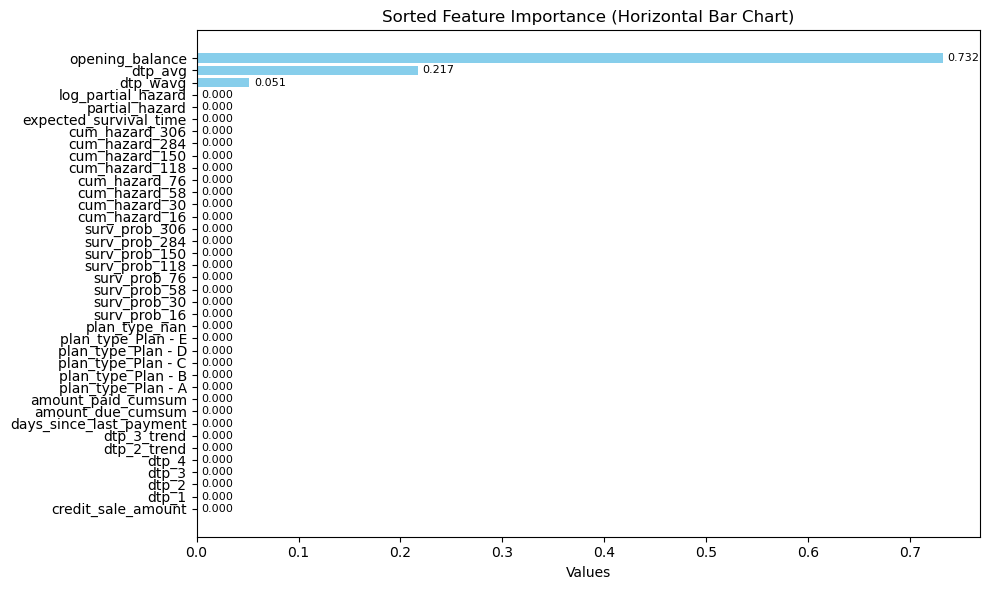

In [38]:
import matplotlib.pyplot as plt

# Your data
top_1_model = results_df.sort_values(by="enhanced_f1_macro", ascending=False).head(1)
data = top_1_model.enhanced_feature_weights.reset_index(drop=True)[0]

# Sort data by value
sorted_data = dict(sorted(data.items(), key=lambda item: item[1], reverse=False))

labels = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(labels, values, color='skyblue')
plt.xlabel("Values")
plt.title("Sorted Feature Importance (Horizontal Bar Chart)")

# Add value labels next to bars
for i, v in enumerate(values):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
results['model_results_df'].model.unique()

array(['two_stage_xgb_xgb', 'two_stage_xgb_rf', 'two_stage_rf_rf',
       'two_stage_xgb_ada', 'two_stage_rf_ada', 'two_stage_ada_xgb'],
      dtype=object)

In [ ]:
results['model_results_df']['model']['two_stage_xgb_ada']

In [ ]:
len(results['model_results_df'].model)

In [ ]:
results_df.columns

In [ ]:
results['class_mappings']

In [ ]:
results['metadata']

In [ ]:
results['survival_results']

In [6]:
from src.modules.machine_learning.utils.io.migrate_db_schema import SchemaV1Migrator

db_path = r".\Results - Backup"

migrator = SchemaV1Migrator(db_path=db_path, keep_db=True)

In [8]:
source_folder = r".\Results - Backup"
dest_folder = r".\Results - Test"

migrator.migrate_all(results_root=source_folder, source_folder=source_folder, dest_folder=dest_folder, keep_db=True)

[migrate] Found 17 session folder(s) under 'C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Backup'
[migrate] Destination folder: 'C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test'
[migrate] COPIED source DB to:     .\Results - Test\2026_03_19_01\results.db
[migrate] BACKUP created:          .\Results - Test\2026_03_19_01\results.db.bak
[migrate] START migrating:         .\Results - Test\2026_03_19_01\results.db
[migrate]   Read 330 row(s) from v1 schema, 27 column(s)
[migrate]   Dropped legacy 'results' table from .\Results - Test\2026_03_19_01\results.db
[migrate] DONE  (330 rows):      .\Results - Test\2026_03_19_01\results.db
[migrate] COPIED source DB to:     .\Results - Test\2026_03_18_01\results.db
[migrate] BACKUP created:          .\Results - Test\2026_03_18_01\results.db.bak
[migrate] START migrating:         .\Results - Test\2026_03_18_01\results.db
[migrate]   Read 870 row(s) from v1 schema, 27 column(s)
[migrate]   Dropped legacy 'results' t

[MigrationResult(status='migrated', rows_migrated=330, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_19_01\\results.db'),
 MigrationResult(status='migrated', rows_migrated=870, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_18_01\\results.db'),
 MigrationResult(status='migrated', rows_migrated=870, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_16_01\\results.db'),
 MigrationResult(status='migrated', rows_migrated=720, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_15_02\\results.db'),
 MigrationResult(status='migrated', rows_migrated=540, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_15_01\\results.db'),
 MigrationResult(status='migrated', rows_migrated=72, db='C:\\Users\\rjbel\\Python\\Notebooks\\Mapua\\Thesis\\Results - Test\\2026_03_14_05\\results.db'),
 MigrationResult(status='migrated', rows_migrated=280, db='C:\\Us